In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Imports

We begin by importing the necessary Python libraries:

- **pandas** — for loading, manipulating, and cleaning the dataset
- **numpy** — for numerical operations and handling missing values
- **matplotlib** — the base library for creating visualizations
- **seaborn** — built on top of matplotlib, used for statistical charts and cleaner visuals
- **%matplotlib inline** — ensures all charts render directly inside the notebook rather than opening in a separate window

# Hospital Readmission Risk Analysis
## Diabetes Patients Across 130 US Hospitals (1999–2008)

**Business Question:** What factors are most associated with early hospital readmission (under 30 days) in diabetic patients, and how can hospitals reduce them?

## Analysis Flow

Sub-question 1 — What is the overall readmission rate?
↓
Sub-question 2 — Which age groups are readmitted most?
↓
Sub-question 3 — Does time in hospital affect readmission?
↓
Sub-question 4 — Do more medications/diagnoses correlate with readmission?
↓
Sub-question 5 — Which medical specialties have highest readmission rates?
↓
Sub-question 6 — Does medication change reduce readmission?
↓
Key Findings — Answer the big business question with evidence

## Section 1 — Load Data & First Look
We load the raw dataset and take a first look at its shape, columns, and contents before touching anything.

In [52]:
df = pd.read_csv("/Users/mahermohamed/hospital-readmissions/data/diabetic_data.csv")
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Initial Data Assessment
Let's check column types, missing values, and basic statistics before touching anything.

In [53]:
df.dtypes

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

In [54]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [55]:
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

## Section 2 — Data Cleaning

### Step 1 — Replace ? with NaN
The dataset uses ? to represent missing values. We replace these with NaN so pandas can detect and handle them properly.

In [56]:
df.replace('?', np.nan, inplace=True)
print("? values replaced with NaN")
df.isnull().sum()[df.isnull().sum() > 0]

? values replaced with NaN


race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

### Step 2 — Drop Irrelevant and Unusable Columns 
We drop columns that are either irrelevant to our business question or have 
too much missing data to be useful.

In [57]:
cols_to_drop = [
    'weight',                      # 97% missing
    'payer_code',                  # not clinically relevant
    'examide',                     # no variation
    'citoglipton',                 # no variation
    'acetohexamide',               # no variation
    'glimepiride-pioglitazone',    # no variation
    'metformin-rosiglitazone',     # no variation
    'metformin-pioglitazone'       # no variation
]

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Columns remaining: {df.shape[1]}")

Columns remaining: 42


### Step 3 — Remove Duplicate Patients
Some patients appear multiple times. We keep only their first encounter to avoid skewing readmission rates upward.

In [58]:
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first')
print(f"Rows after removing duplicates: {df.shape[0]}")

Rows after removing duplicates: 71518


### Step 4 — Fill Missing Categorical Values
Rather than dropping rows with missing categorical data, we fill with 'Unknown' to preserve the rest of the row's data.

In [59]:
df = df.fillna({
    'race': 'Unknown',
    'medical_specialty': 'Unknown',
    'diag_1': 'Unknown',
    'diag_2': 'Unknown',
    'diag_3': 'Unknown'
})

print("Missing values after fill:")
df.isnull().sum()[df.isnull().sum() > 0]

Missing values after fill:


max_glu_serum    68062
A1Cresult        58532
dtype: int64

### Step 5 — Drop Invalid Gender Rows
Only 3 rows contain 'Unknown/Invalid' gender. These are dropped as they are negligible and cannot be imputed.

In [60]:
df = df[df['gender'] != 'Unknown/Invalid']
print(f"Rows remaining: {df.shape[0]}")

Rows remaining: 71515


### Step 6 — Create Readmission Target Variables

The readmitted column has 3 possible outcomes: under 30 days, over 30 days, and no readmission at all. 

We create two columns from it:
- **readmission_status** — keeps all 3 outcomes so we can visualize the full picture
- **early_readmission** — a simple yes or no column where 1 means the patient came back within 30 days and 0 means they did not

We focus on early readmission because that is the outcome hospitals are penalized for and the core of our business question.

In [61]:
# Map all 3 readmission outcomes clearly
df['readmission_status'] = df['readmitted'].map({
    '<30': 'Early Readmission',
    '>30': 'Late Readmission',
    'NO': 'No Readmission'
})

# Also keep a binary column specifically for early readmission (our main focus)
df['early_readmission'] = (df['readmitted'] == '<30').astype(int)

print(df['readmission_status'].value_counts())
print(df['early_readmission'].value_counts())

readmission_status
No Readmission       42982
Late Readmission     22240
Early Readmission     6293
Name: count, dtype: int64
early_readmission
0    65222
1     6293
Name: count, dtype: int64


### Step 7 — Keep Only Relevant Columns

We narrow the dataset down to only the columns that are relevant to our business question before exporting. This keeps the cleaned file lean and focused.

In [62]:
cols_to_keep = [
    'race', 'gender', 'age',
    'time_in_hospital', 'admission_type_id', 
    'discharge_disposition_id', 'admission_source_id', 'medical_specialty',
    'num_lab_procedures', 'num_procedures', 'num_medications',
    'number_diagnoses', 'number_outpatient', 'number_emergency', 'number_inpatient',
    'diag_1', 'diag_2', 'diag_3',
    'max_glu_serum', 'A1Cresult',
    'insulin', 'metformin', 'change', 'diabetesMed',
    'readmitted', 'readmission_status', 'early_readmission'
]

df = df[cols_to_keep]
print(f"Final columns: {df.shape[1]}")
print(f"Final rows: {df.shape[0]}")
df.head()

Final columns: 27
Final rows: 71515


,race,gender,age,time_in_hospital,admission_type_id,discharge_disposition_id,admission_source_id,medical_specialty,num_lab_procedures,num_procedures,...,diag_3,max_glu_serum,A1Cresult,insulin,metformin,change,diabetesMed,readmitted,readmission_status,early_readmission
8,Caucasian,Female,[80-90),13,2,1,4,Unknown,68,2,...,38,NaN,NaN,Steady,No,Ch,Yes,NO,No Readmission,0
9,Caucasian,Female,[90-100),12,3,3,4,InternalMedicine,33,3,...,486,NaN,NaN,Steady,No,Ch,Yes,NO,No Readmission,0
4,Caucasian,Male,[40-50),1,1,1,7,Unknown,51,0,...,250,NaN,NaN,Steady,No,Ch,Yes,NO,No Readmission,0
10,AfricanAmerican,Female,[40-50),9,1,1,7,Unknown,47,2,...,996,NaN,NaN,Steady,No,No,Yes,>30,Late Readmission,0
5,Caucasian,Male,[50-60),3,2,1,2,Unknown,31,6,...,250,NaN,NaN,Steady,No,No,Yes,>30,Late Readmission,0


### Step 8 — Save Cleaned Dataset
We export the cleaned dataframe to a new CSV, leaving the original raw data untouched.

In [63]:
df.to_csv("/Users/mahermohamed/hospital-readmissions/data/diabetic_data_cleaned.csv", index=False)
print("Cleaned dataset saved successfully")

Cleaned dataset saved successfully


## Section 3 — Exploratory Data Analysis

Now that the data is clean we begin exploring it to answer our business question:

**What factors are most associated with early hospital readmission in diabetic patients?**

We work through each sub-question one at a time, building evidence toward a final conclusion.

### Sub-question 1 — What is the overall readmission rate?

Before diving into specific factors, we need to understand the baseline. How many patients were readmitted early, late, or not at all?

In [64]:
readmission_counts = df['readmission_status'].value_counts()
readmission_pct = df['readmission_status'].value_counts(normalize=True) * 100

print("Readmission Counts:")
print(readmission_counts)
print("\nReadmission Percentages:")
print(readmission_pct.round(2))

Readmission Counts:
readmission_status
No Readmission       42982
Late Readmission     22240
Early Readmission     6293
Name: count, dtype: int64

Readmission Percentages:
readmission_status
No Readmission       60.1
Late Readmission     31.1
Early Readmission     8.8
Name: proportion, dtype: float64


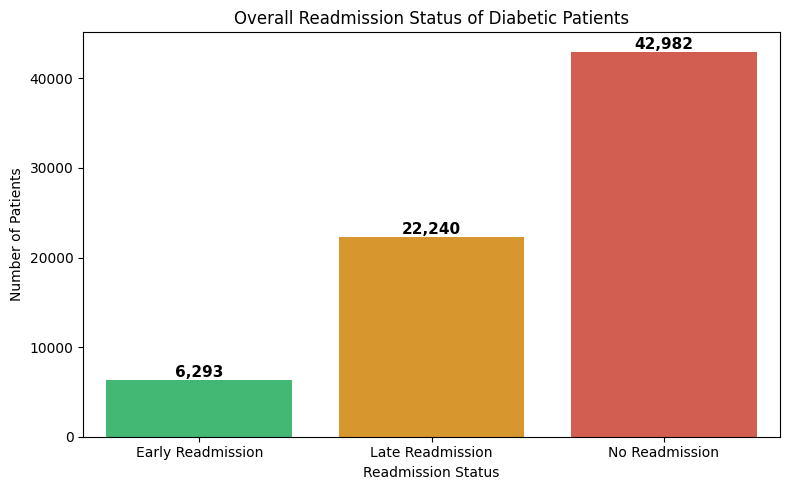

In [65]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='readmission_status',
              order=['Early Readmission', 'Late Readmission', 'No Readmission'],
              palette=['#e74c3c', '#f39c12', '#2ecc71'],
              hue='readmission_status',
              legend=False)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Overall Readmission Status of Diabetic Patients')
plt.xlabel('Readmission Status')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

#### Observation
The majority of patients — 60.1% — were not readmitted after their initial visit. 
31.1% were readmitted after 30 days and 8.8% were readmitted within 30 days.

That early readmission group of 6,293 patients, while the smallest, represents the 
highest risk patients and the ones hospitals face financial penalties for. 
This group is the focus of the rest of our analysis.

### Sub-question 2 — Which age groups are readmitted most?

Age is one of the most commonly cited risk factors for hospital readmission. 
Here we look at how early readmission rates vary across age groups.

In [66]:
age_readmission = df.groupby('age')['early_readmission'].mean() * 100
age_readmission = age_readmission.reset_index()
age_readmission.columns = ['age', 'early_readmission_rate']
age_readmission = age_readmission.sort_values('age')
print(age_readmission)

        age  early_readmission_rate
0    [0-10)                1.948052
1   [10-20)                4.859813
2   [20-30)                7.364685
3   [30-40)                6.965543
4   [40-50)                7.371329
5   [50-60)                7.051179
6   [60-70)                8.860204
7   [70-80)               10.017575
8   [80-90)               10.363276
9  [90-100)                8.842105


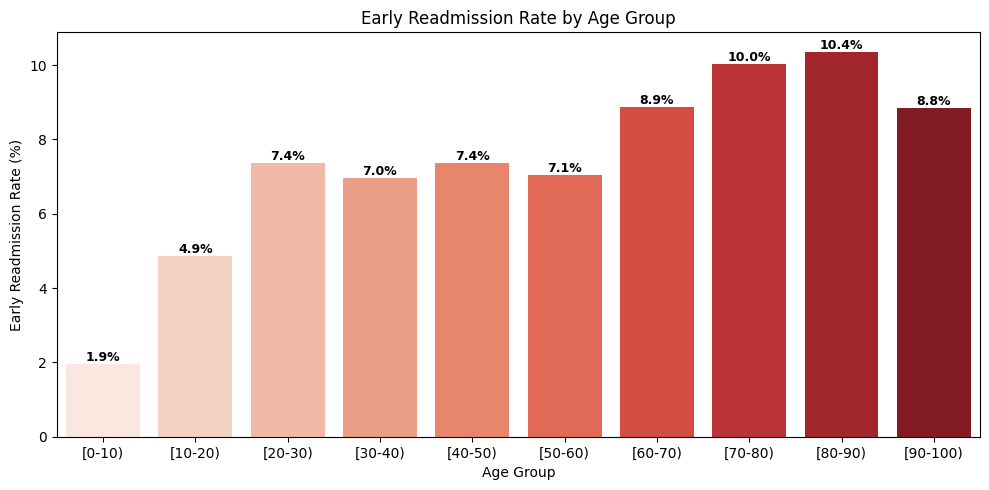

In [67]:
plt.figure(figsize=(10, 5))
sns.barplot(data=age_readmission, x='age', y='early_readmission_rate',
            hue='age', palette='Reds', legend=False)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Early Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Early Readmission Rate (%)')
plt.tight_layout()
plt.show()

#### Observation
Early readmission rates increase steadily with age. Younger patients under 20 
have the lowest rates at 1.9% and 4.9%, while patients in the 80-90 age group 
have the highest early readmission rate at 10.4%.

The pattern is clear — patients aged 60 and older are significantly more likely 
to be readmitted within 30 days. This suggests that older diabetic patients require 
more intensive post-discharge care and follow-up to prevent early returns to the hospital.

### Sub-question 3 — Does time spent in the hospital affect readmission?

Longer hospital stays may indicate more severe cases. Here we examine whether 
the number of days a patient spends in the hospital is associated with early readmission.

In [68]:
time_readmission = df.groupby('time_in_hospital')['early_readmission'].mean() * 100
time_readmission = time_readmission.reset_index()
time_readmission.columns = ['Days in Hospital', 'Early Readmission Rate']
print(time_readmission.to_string(index=False, float_format=lambda x: f'{x:.1f}%'))

 Days in Hospital  Early Readmission Rate
                1                    6.4%
                2                    7.6%
                3                    8.1%
                4                    8.7%
                5                    9.6%
                6                   10.7%
                7                   11.2%
                8                   12.0%
                9                   11.9%
               10                   11.9%
               11                    9.3%
               12                   11.9%
               13                   10.1%
               14                   11.1%


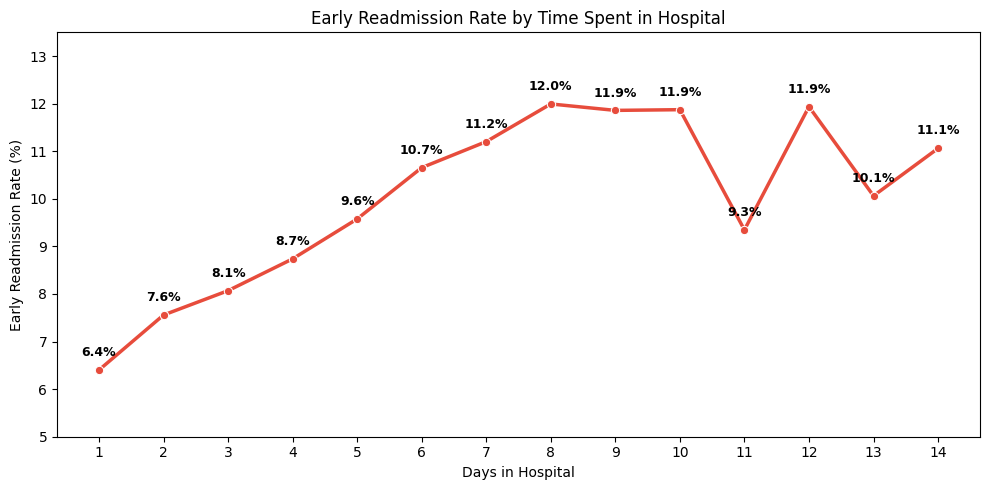

In [69]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=time_readmission, x='Days in Hospital', y='Early Readmission Rate',
             marker='o', color='#e74c3c', linewidth=2.5, ax=ax)

for _, row in time_readmission.iterrows():
    ax.annotate(f"{row['Early Readmission Rate']:.1f}%",
                (row['Days in Hospital'], row['Early Readmission Rate']),
                textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9, fontweight='bold')

plt.title('Early Readmission Rate by Time Spent in Hospital')
plt.xlabel('Days in Hospital')
plt.ylabel('Early Readmission Rate (%)')
plt.xticks(range(1, 15))
plt.ylim(5, 13.5)
plt.tight_layout()
plt.show()

#### Observation
There is a clear upward trend in the first half of the chart — patients who stayed 
just 1 day had a 6.4% early readmission rate, rising steadily to a peak of 12.0% 
at 8 days in the hospital.

After 8 days the rate fluctuates but stays elevated between 9% and 12%, never 
dropping back to the lower rates seen in shorter stays.

This suggests that longer hospital stays are associated with more complex or severe 
cases that are harder to fully resolve, leading to a higher chance of returning within 
30 days. Hospitals should prioritize thorough discharge planning for patients with 
extended stays.

### Sub-question 4 — Do more medications or diagnoses correlate with readmission?

Patients with more medications and diagnoses likely have more complex medical 
conditions. Here we examine whether that complexity is associated with higher 
early readmission rates.

In [70]:
med_readmission = df.groupby('num_medications').agg(
    Patients=('early_readmission', 'count'),
    Early_Readmission_Rate=('early_readmission', 'mean')
).reset_index()
med_readmission['Early_Readmission_Rate'] = (med_readmission['Early_Readmission_Rate'] * 100).round(1)
med_readmission.columns = ['Number of Medications', 'Number of Patients', 'Early Readmission Rate']

diag_readmission = df.groupby('number_diagnoses').agg(
    Patients=('early_readmission', 'count'),
    Early_Readmission_Rate=('early_readmission', 'mean')
).reset_index()
diag_readmission['Early_Readmission_Rate'] = (diag_readmission['Early_Readmission_Rate'] * 100).round(1)
diag_readmission.columns = ['Number of Diagnoses', 'Number of Patients', 'Early Readmission Rate']

print("Medications vs Early Readmission Rate:")
print(med_readmission.to_string(index=False))
print("\nDiagnoses vs Early Readmission Rate:")
print(diag_readmission.to_string(index=False))

Medications vs Early Readmission Rate:
 Number of Medications  Number of Patients  Early Readmission Rate
                     1                 216                     4.2
                     2                 399                     7.0
                     3                 727                     5.4
                     4                1169                     5.7
                     5                1631                     5.9
                     6                2128                     7.1
                     7                2701                     6.8
                     8                3304                     7.5
                     9                3669                     8.1
                    10                3914                     7.9
                    11                4080                     8.4
                    12                4321                     8.7
                    13                4332                     8.9
                    14 

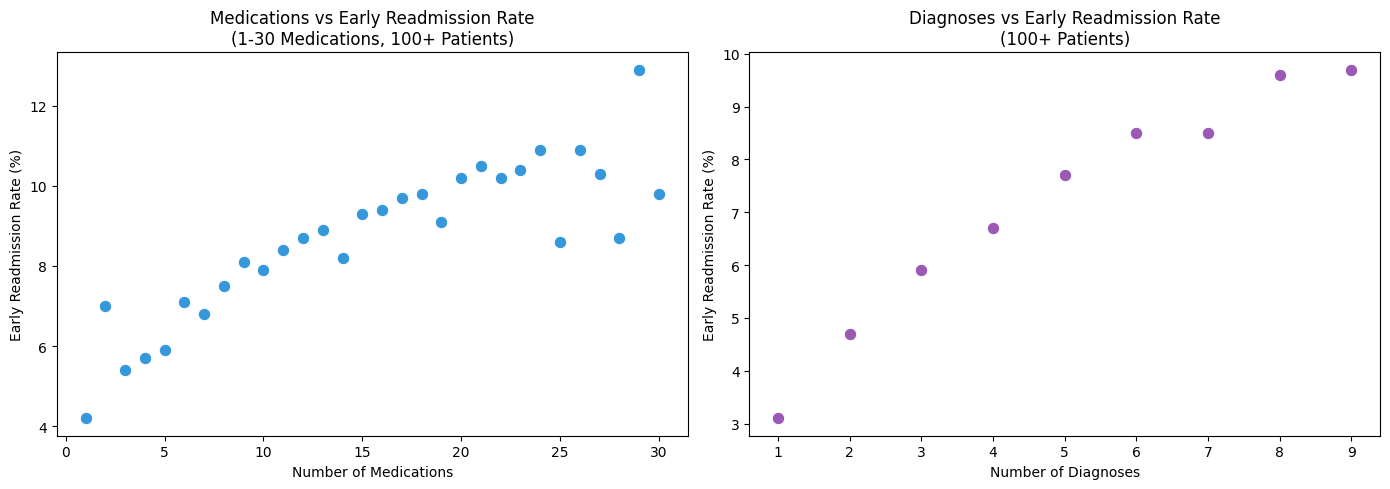

In [71]:
med_filtered = med_readmission[
    (med_readmission['Number of Patients'] >= 100) & 
    (med_readmission['Number of Medications'] <= 30)
]

diag_filtered = diag_readmission[
    diag_readmission['Number of Patients'] >= 100
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=med_filtered, x='Number of Medications',
                y='Early Readmission Rate', color='#3498db', s=80, ax=axes[0])
axes[0].set_title('Medications vs Early Readmission Rate\n(1-30 Medications, 100+ Patients)')
axes[0].set_xlabel('Number of Medications')
axes[0].set_ylabel('Early Readmission Rate (%)')

sns.scatterplot(data=diag_filtered, x='Number of Diagnoses',
                y='Early Readmission Rate', color='#9b59b6', s=80, ax=axes[1])
axes[1].set_title('Diagnoses vs Early Readmission Rate\n(100+ Patients)')
axes[1].set_xlabel('Number of Diagnoses')
axes[1].set_ylabel('Early Readmission Rate (%)')

plt.tight_layout()
plt.show()

#### Observation
Both medications and diagnoses show a clear upward trend in early readmission 
rates, confirming that patient complexity is a strong risk factor.

**Medications:** Patients on 1 medication had a 4.2% early readmission rate, 
rising steadily to a peak of 12.9% for patients on 29 medications. The scatter 
plot shows a consistent upward trend across the entire range, meaning the more 
medications a patient is managing, the more likely they are to return within 
30 days. This makes clinical sense — patients on many medications are typically 
dealing with multiple chronic conditions that are harder to fully stabilize in 
a single visit.

**Diagnoses:** Patients with 1 diagnosis had a 3.1% early readmission rate, 
climbing steadily to 9.7% for patients with 9 diagnoses. The more conditions 
a patient has, the harder it is to fully resolve everything in one hospital stay.

**Data quality note:** Medication counts above 30 were excluded due to very small 
sample sizes and clinically unrealistic values. Having 50-80+ medications is not 
realistic for a single patient — these likely reflect data entry errors or the 
hospital system counting IV fluids and individual doses as separate medications. 
Diagnoses above 9 also drop to fewer than 10 patients per group, suggesting the 
hospital system capped recording at 9 diagnoses per visit. The one exception is 
16 diagnoses which shows 31 patients, but this is still too small to draw 
meaningful conclusions from.

### Sub-question 5 — Which medical specialties have the highest readmission rates?

Not all hospital departments are equal when it comes to readmission. A patient 
treated in cardiology is dealing with very different conditions than a patient 
in general surgery. Here we look at which specialties see their patients return 
within 30 days most often.

In [72]:
specialty_readmission = df.groupby('medical_specialty').agg(
    Patients=('early_readmission', 'count'),
    Early_Readmission_Rate=('early_readmission', 'mean')
).reset_index()

specialty_readmission['Early_Readmission_Rate'] = (specialty_readmission['Early_Readmission_Rate'] * 100).round(1)
specialty_readmission.columns = ['Medical Specialty', 'Number of Patients', 'Early Readmission Rate']

# Filter to only specialties with 100+ patients
specialty_filtered = specialty_readmission[specialty_readmission['Number of Patients'] >= 100]
specialty_filtered = specialty_filtered.sort_values('Early Readmission Rate', ascending=False)

print(specialty_filtered.to_string(index=False))

                Medical Specialty  Number of Patients  Early Readmission Rate
              Hematology/Oncology                 122                    18.0
                         Oncology                 218                    17.0
PhysicalMedicineandRehabilitation                 194                    12.9
                 Surgery-Vascular                 362                    11.9
                       Psychiatry                 614                    11.1
                       Nephrology                 828                    10.6
                 Gastroenterology                 398                    10.1
                      Orthopedics                1134                     9.9
           Family/GeneralPractice                5118                     9.5
                 InternalMedicine               10919                     9.5
                      Pulmonology                 653                     9.2
                          Unknown               34475           

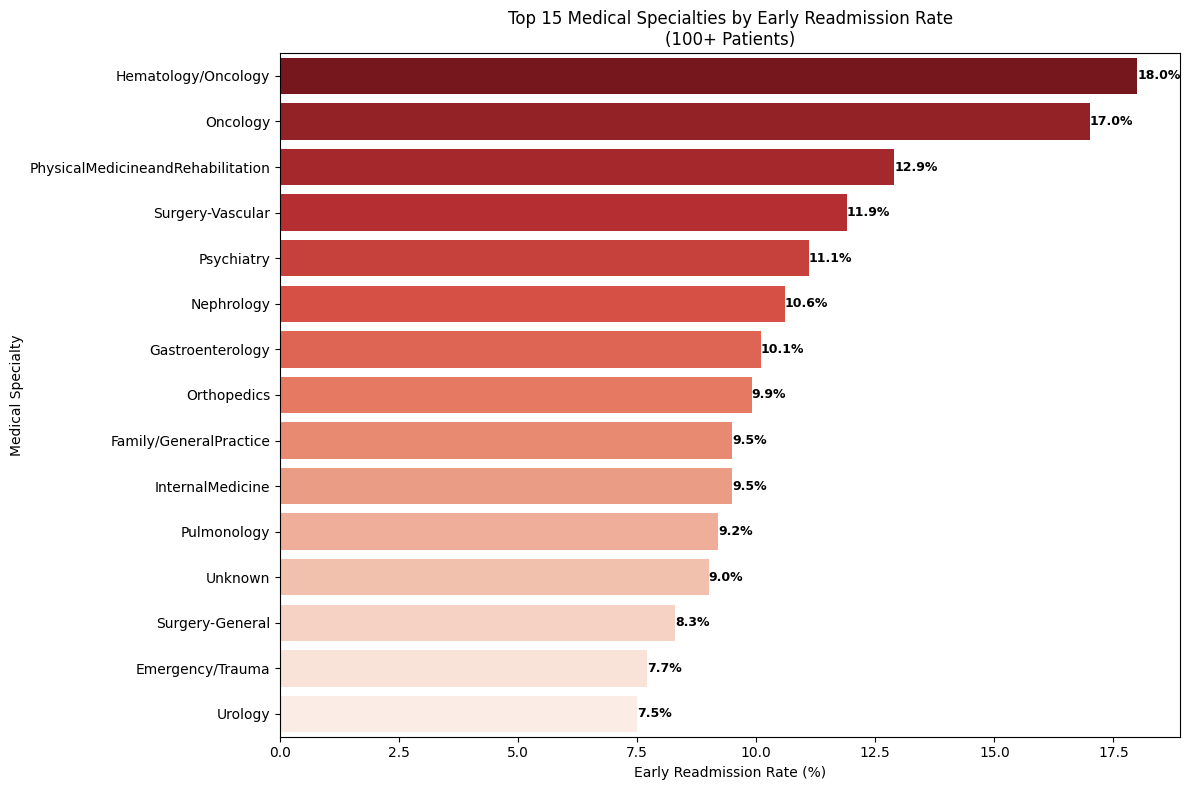

In [73]:
plt.figure(figsize=(12, 8))
sns.barplot(data=specialty_filtered.head(15), 
            x='Early Readmission Rate', y='Medical Specialty',
            hue='Medical Specialty', palette='Reds_r', legend=False)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, fontweight='bold')

plt.title('Top 15 Medical Specialties by Early Readmission Rate\n(100+ Patients)')
plt.xlabel('Early Readmission Rate (%)')
plt.ylabel('Medical Specialty')
plt.tight_layout()
plt.show()

#### Observation
Hematology/Oncology and Oncology have the highest early readmission rates at 18.0% 
and 17.0% respectively. This is expected — cancer patients undergo aggressive 
treatments like chemotherapy that weaken the body, making complications and return 
visits far more likely within 30 days.

Physical Medicine and Rehabilitation comes in third at 12.9%. These are patients 
recovering from major events like strokes or surgeries, whose recovery is complex 
and often requires multiple hospital stays.

Surgery-Vascular at 11.9% and Psychiatry at 11.1% round out the top 5. Vascular 
surgery patients deal with serious circulatory conditions that are difficult to 
fully resolve, while psychiatric patients often face challenges with medication 
management and follow-up care after discharge.

Notably Internal Medicine and Family/General Practice both sit at 9.5% but 
represent by far the largest patient volumes — 10,919 and 5,118 patients 
respectively. Even a small reduction in readmission rates for these specialties 
would have a significant impact at scale.

The Unknown category with 34,475 patients and a 9.0% rate highlights the data 
quality issue we addressed in cleaning — nearly half the dataset had no recorded 
specialty, which limits how deeply we can analyze this dimension.

### Sub-question 6 — Does a change in diabetes medication reduce readmission?

One of the key treatment decisions during a hospital visit is whether to adjust 
a patient's diabetes medication. Here we examine whether patients whose medication 
was changed during their visit had lower early readmission rates than those whose 
medication stayed the same.

In [74]:
change_readmission = df.groupby('change').agg(
    Patients=('early_readmission', 'count'),
    Early_Readmission_Rate=('early_readmission', 'mean')
).reset_index()

change_readmission['Early_Readmission_Rate'] = (change_readmission['Early_Readmission_Rate'] * 100).round(1)
change_readmission.columns = ['Medication Change', 'Number of Patients', 'Early Readmission Rate']
change_readmission['Medication Change'] = change_readmission['Medication Change'].map({
    'Ch': 'Medication Changed',
    'No': 'No Change'
})

print(change_readmission.to_string(index=False))

 Medication Change  Number of Patients  Early Readmission Rate
Medication Changed               32022                     9.3
         No Change               39493                     8.4


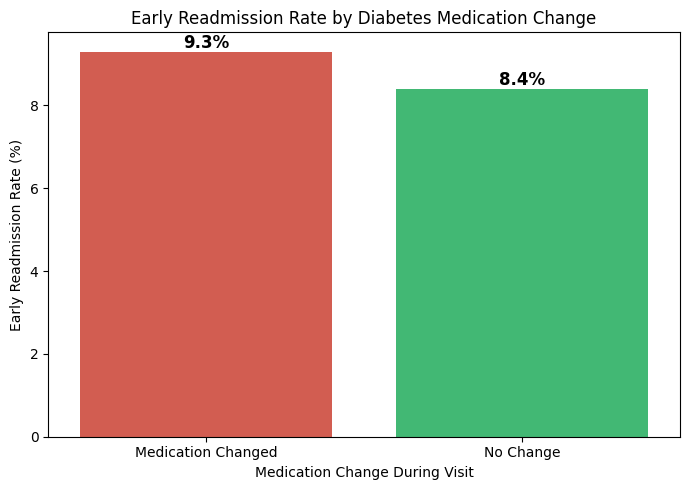

In [75]:
plt.figure(figsize=(7, 5))
ax = sns.barplot(data=change_readmission, x='Medication Change', y='Early Readmission Rate',
            hue='Medication Change', palette=['#e74c3c', '#2ecc71'], legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Early Readmission Rate by Diabetes Medication Change')
plt.xlabel('Medication Change During Visit')
plt.ylabel('Early Readmission Rate (%)')
plt.tight_layout()
plt.show()

#### Observation
Patients whose diabetes medication was changed during their visit had a slightly 
higher early readmission rate at 9.3% compared to 8.4% for patients whose 
medication was not changed.

At first glance this seems counterintuitive — shouldn't changing medication help? 
However this finding makes sense when you think about it clinically. Doctors are 
more likely to change a patient's medication when their diabetes is poorly 
controlled or their condition is more severe. In other words medication changes 
are a response to sicker patients, not a cause of readmission.

This is a classic example of correlation vs causation. The medication change 
did not cause the higher readmission — both the medication change and the 
readmission are symptoms of the same underlying issue: a more complex, 
harder to manage patient.

This finding suggests that the severity of a patient's condition at admission 
is a stronger predictor of readmission than any single treatment decision made 
during the visit.

## Section 4 — Key Findings

Having worked through each sub-question, we can now answer our core business question:

**What factors are most associated with early hospital readmission in diabetic 
patients, and how can hospitals reduce them?**

Based on our analysis of 71,515 unique diabetic patients across 130 US hospitals 
between 1999 and 2008, here is what we found:

### Finding 1 — Early Readmission Affects 1 in 11 Diabetic Patients
8.8% of diabetic patients — roughly 1 in 11 — were readmitted within 30 days 
of discharge. This represents 6,293 patients in our cleaned dataset, each one 
a potential financial penalty for the hospital and a sign of incomplete care.

### Finding 2 — Older Patients Are at Significantly Higher Risk
Patients aged 80-90 had the highest early readmission rate at 10.4%, nearly 
double the rate of patients under 20. Hospitals should prioritize post-discharge 
follow-up programs specifically for elderly diabetic patients.

### Finding 3 — Longer Hospital Stays Do Not Prevent Readmission
Patients who stayed longer were more likely to return within 30 days, peaking 
at 12.0% for 8-day stays. This suggests longer stays reflect case severity 
rather than better care — discharge planning quality matters more than length 
of stay.

### Finding 4 — Patient Complexity Is a Strong Predictor
Both medication count and diagnosis count showed clear upward trends. Patients 
on 29 medications had a 12.9% readmission rate compared to 4.2% for patients 
on 1 medication. More complex patients need more intensive post-discharge support.

### Finding 5 — Oncology Patients Face the Highest Risk
Hematology/Oncology and Oncology had the highest early readmission rates at 
18.0% and 17.0% respectively. Cancer patients undergoing aggressive treatment 
are the highest risk group and require dedicated readmission prevention programs.

### Finding 6 — Medication Changes Signal Severity, Not Cause
Patients whose diabetes medication was changed had a slightly higher readmission 
rate at 9.3% vs 8.4%. This is a classic example of correlation vs causation — 
sicker patients are more likely to have medication adjusted and more likely to 
be readmitted, but one does not cause the other.

### Recommendations for Hospitals

Based on these findings, hospitals looking to reduce early readmissions in 
diabetic patients should:

1. **Target elderly patients** — implement dedicated follow-up calls and 
outpatient check-ins for patients aged 60 and above within 7 days of discharge
2. **Flag high complexity patients** — patients with 15+ medications or 7+ 
diagnoses should receive enhanced discharge planning
3. **Prioritize oncology departments** — cancer patients need specialized 
readmission prevention programs given their 17-18% readmission rates
4. **Focus on discharge quality over length of stay** — longer stays do not 
reduce readmission, so resources should go toward better discharge instructions 
and follow-up care